# Escape Response Latency in the *Drosophila* Giant Fiber System

Workshop 3 -- Pena Lab Project -- Spring 2026

This notebook walks through a simplified Brian2 model of the *Drosophila melanogaster* giant fiber system (GFS), based on Augustin, Zylbertal & Partridge (eNeuro, 2019). The original paper was implemented in NEURON; our project goal is to replicate it in Brian2.

Latency = time from stimulus at the giant fiber to motor neuron activation.

### What this notebook covers
1. Environment setup and imports (Weeks 1-2)
2. Neuron equations from the paper (Week 3 / Brian2 basics)
3. GFS circuit: GF, TTMn, PSI, DLMn connected by gap junctions and a chemical synapse (Week 4 / paper reading)
4. Stimulus, simulation, and latency measurement (Week 6 / model building)
5. Parameter exploration: how g_gap affects latency (Weeks 7-8 preview)

---
## 1 -- Imports and Environment

Brian2 is a Python-based neural simulator. We also use NumPy and Matplotlib.

To set up your environment: `conda env create -f environment.yml`, then `conda activate <env_name>`.

In [79]:
import brian2
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

brian2.prefs.codegen.target = 'numpy'

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 12

print(f'Brian2 version: {brian2.__version__}')

Brian2 version: 2.4.2


---
## 2 -- Neuron Equations

The paper (Augustin et al., 2019) uses channel kinetics from Gunay et al. (2015). These are *not* classic Hodgkin-Huxley alpha/beta equations -- they use Boltzmann steady-state activation and voltage-dependent time constants.

Channels in the original NEURON model:
- **Transient Na (nat):** $g_{Na_t} \cdot m^3 h \cdot (V - E_{Na})$, with Boltzmann $m_\infty$, $h_\infty$ and voltage-dependent $\tau_m$, $\tau_h$
- **Persistent Na (nap):** $g_{Na_p} \cdot m \cdot (V - E_{Na})$, Boltzmann $m_\infty$, constant $\tau_m = 1$ ms
- **Potassium (k):** $g_K \cdot m \cdot (V - E_K)$, Boltzmann $m_\infty$, constant $\tau_m = 1$ ms (note: single gate, not $m^4$)
- **Leak (pas):** $g_L \cdot (V - E_L)$

Parameters from Table 1 of the paper.

In [80]:
start_scope()

# Parameters from Table 1 (Augustin et al., 2019; Gunay et al., 2015)
C_m    = 1 * uF / cm**2
g_NaT  = 300 * msiemens / cm**2   # transient Na
g_NaP  = 0.11 * msiemens / cm**2  # persistent Na
g_K    = 10 * msiemens / cm**2     # potassium
g_L    = 0.03 * msiemens / cm**2   # leak
E_Na   = 65 * mV
E_K    = -74 * mV
E_L    = -85 * mV

# Neuron equations using Boltzmann kinetics from Gunay et al., 2015
# Steady-state: minf = 1/(1+exp((v - v1_2)/k)) where k values
# are negative for activation gates and positive for inactivation.
neuron_eqs = '''
    dv/dt = (-g_NaT*m_NaT**3*h_NaT*(v - E_Na)
             -g_NaP*m_NaP*(v - E_Na)
             -g_K*m_K*(v - E_K)
             -g_L*(v - E_L)
             + I_syn + I_ext) / C_m : volt

    # Transient Na activation: v1_2=-29.13, k=-8.92
    dm_NaT/dt = (minf_NaT - m_NaT) / mtau_NaT : 1
    minf_NaT = 1.0 / (1.0 + exp((v/mV + 29.13) / (-8.92))) : 1
    mtau_NaT = (0.13 + 3.43 / (1.0 + exp((v/mV + 45.35) / 5.98))) * ms : second

    # Transient Na inactivation: v1_2=-47, k=5
    dh_NaT/dt = (hinf_NaT - h_NaT) / htau_NaT : 1
    hinf_NaT = 1.0 / (1.0 + exp((v/mV + 47.0) / 5.0)) : 1
    htau_NaT = (0.36 + exp((v/mV + 20.65) / -10.47)) * ms : second

    # Persistent Na activation: v1_2=-48.77, k=-3.68
    dm_NaP/dt = (minf_NaP - m_NaP) / tau_NaP : 1
    minf_NaP = 1.0 / (1.0 + exp((v/mV + 48.77) / (-3.68))) : 1
    tau_NaP = 1.0 * ms : second

    # Potassium activation: v1_2=-12.85, k=-19.91 (single gate, not m^4)
    dm_K/dt = (minf_K - m_K) / tau_K : 1
    minf_K = 1.0 / (1.0 + exp((v/mV + 12.85) / (-19.91))) : 1
    tau_K = 1.0 * ms : second

    I_syn : amp/meter**2
    I_ext : amp/meter**2
'''

print('Neuron equations defined (Gunay et al., 2015 kinetics).')

Neuron equations defined (Gunay et al., 2015 kinetics).


---
## 3 -- GFS Circuit Architecture

From Figure 2A of the paper, the giant fiber system has four cells:
- **GF** (giant fiber): receives stimulus, relays signal via electrical synapses
- **TTMn** (TTM motor neuron): drives the jump muscle, receives gap junction from GF
- **PSI** (peripherally synapsing interneuron): receives gap junction from GF
- **DLMn** (DLM motor neuron): drives the flight muscle, receives chemical synapse from PSI

In the original NEURON model each cell has multiple compartments. Here we simplify to single-compartment neurons to focus on the circuit-level behavior.

Gap junctions are electrical synapses where current flows proportional to the voltage difference:
$I_{gap} = g_{gap} \cdot (V_{pre} - V_{post})$

The PSI-to-DLMn synapse is chemical (modeled as a double-exponential conductance).

In [81]:
# Create the four neuron groups (single-compartment simplification)
GF = NeuronGroup(1, neuron_eqs, threshold='v > -20*mV', refractory=2*ms,
                 method='euler', dt=0.01*ms)
TTMn = NeuronGroup(1, neuron_eqs, threshold='v > -20*mV', refractory=2*ms,
                   method='euler', dt=0.01*ms)
PSI = NeuronGroup(1, neuron_eqs, threshold='v > -20*mV', refractory=2*ms,
                  method='euler', dt=0.01*ms)
DLMn = NeuronGroup(1, neuron_eqs, threshold='v > -20*mV', refractory=2*ms,
                   method='euler', dt=0.01*ms)

# Initial conditions at resting potential
V_rest = -65 * mV
for group in [GF, TTMn, PSI, DLMn]:
    group.v = V_rest
    # Initialize gating variables at steady state for V_rest (-65 mV)
    # minf = 1/(1+exp((v - v1_2)/k))
    group.m_NaT = 1.0 / (1.0 + np.exp((-65.0 + 29.13) / (-8.92)))   # ~0.018
    group.h_NaT = 1.0 / (1.0 + np.exp((-65.0 + 47.0) / 5.0))        # ~0.973
    group.m_NaP = 1.0 / (1.0 + np.exp((-65.0 + 48.77) / (-3.68)))    # ~0.012
    group.m_K   = 1.0 / (1.0 + np.exp((-65.0 + 12.85) / (-19.91)))   # ~0.068

print('Created neuron groups: GF, TTMn, PSI, DLMn')
print(f'Resting potential: {V_rest}')

Created neuron groups: GF, TTMn, PSI, DLMn
Resting potential: -0.065


---
## 4 -- Gap Junctions and Chemical Synapse

From the paper's NEURON code (`gap2.mod`), the gap junction parameter `g` is declared in **nanosiemens (nS)** with the equation `i = (v - vgap) * g * 0.001` (the 0.001 converts nS·mV to nA). Note: the paper's Figure 2C axis and plotting code label this as µS, but the MOD file and dimensional analysis confirm nS.

- Young fly: g_gap = 135 nS
- Old fly: g_gap = 34.5 nS (a ~4-fold reduction)

Since Brian2 uses current densities (A/m²), we convert absolute conductance to density by dividing by each cell's total membrane area (computed from Table 1 dimensions). Gap junctions are unidirectional: GF drives TTMn and PSI. The PSI-DLMn connection is a chemical synapse (double-exponential, matching NEURON's `Exp2Syn`).

In [82]:
# Membrane areas from Table 1 geometry (for absolute-to-density conversion)
# TTMn: d=6um, total L = axon(50) + med_dendrite(60) + lat_dendrite(30) = 140 um
A_TTMn_cm2 = np.pi * 6e-4 * 140e-4   # 2639 um^2
# PSI: d=4.5um, total L = axon(90) + dendrite(170) = 260 um
A_PSI_cm2  = np.pi * 4.5e-4 * 260e-4  # 3676 um^2
# DLMn: axon (d_mean~3um, L=50um) + dendrite (d=2um, L=100um)
A_DLMn_cm2 = np.pi * (3e-4 * 50e-4 + 2e-4 * 100e-4)  # ~1100 um^2

def nS_to_Sm2(g_nS, area_cm2):
    """Convert absolute conductance (nS) to density (S/m^2)."""
    return g_nS * 1e-9 / (area_cm2 * 1e-4)

# Gap junction conductance -- the key parameter from the paper
# gap2.mod: g in nanosiemens, i = (v-vgap)*g*0.001 converts nS*mV -> nA
# Young fly: 135 nS, Old fly: 34.5 nS
g_gap_nS = 135  # young fly default

# Convert to density for each pathway (different cell areas)
g_gap_TTMn_Sm2 = nS_to_Sm2(g_gap_nS, A_TTMn_cm2)
g_gap_PSI_Sm2  = nS_to_Sm2(g_gap_nS, A_PSI_cm2)

# Separate gap junction equations (different densities for different cell areas)
gap_eqs_TTMn = f'''
    I_syn_post = {g_gap_TTMn_Sm2} * siemens / meter**2 * (v_pre - v_post) : amp/meter**2 (summed)
'''
gap_eqs_PSI = f'''
    I_syn_post = {g_gap_PSI_Sm2} * siemens / meter**2 * (v_pre - v_post) : amp/meter**2 (summed)
'''

syn_GF_TTMn = Synapses(GF, TTMn, model=gap_eqs_TTMn)
syn_GF_TTMn.connect()

syn_GF_PSI = Synapses(GF, PSI, model=gap_eqs_PSI)
syn_GF_PSI.connect()

# Chemical synapse: PSI -> DLMn (double-exponential, excitatory)
# Paper: Exp2Syn with tau1=0.1ms, tau2=1.0ms, e=0mV, weight=0.08 uS, delay=0.15ms
chem_eqs = '''
    dg_syn/dt = -g_syn / tau_d + s : siemens/meter**2 (clock-driven)
    ds/dt = -s / tau_r : siemens/meter**2/second (clock-driven)
    I_syn_post = g_syn * (E_syn - v_post) : amp/meter**2 (summed)
'''
E_syn = 0 * mV
tau_r = 0.1 * ms    # rise time (Table 1: 0.1 ms)
tau_d = 1.0 * ms    # decay time (Table 1: 1.0 ms)

# Convert chemical synapse weight from absolute (NEURON) to density (Brian2)
# NEURON Exp2Syn: peak conductance = weight = 0.08 uS = 80 nS
# For Brian2 double-exponential with tau_r=0.1ms, tau_d=1.0ms:
#   g_peak (mS/cm^2) = w_chem (mS/cm^2/ms) * 0.0774 (ms)
# Target: g_peak = 80 nS / A_DLMn as density
g_peak_mScm2 = 80e-9 / (A_DLMn_cm2 * 1e-4) * 0.1  # S/m^2 -> mS/cm^2
w_chem = (g_peak_mScm2 / 0.0774) * msiemens / cm**2 / ms

syn_PSI_DLMn = Synapses(PSI, DLMn, model=chem_eqs,
                         on_pre='s += w_chem', dt=0.01*ms)
syn_PSI_DLMn.connect()
syn_PSI_DLMn.delay = 0.15 * ms  # chemical synapse delay (Table 1)

print('Synapses created:')
print(f'  GF -> TTMn  (gap junction, g_gap = {g_gap_nS} nS, density = {g_gap_TTMn_Sm2*0.1:.2f} mS/cm^2)')
print(f'  GF -> PSI   (gap junction, g_gap = {g_gap_nS} nS, density = {g_gap_PSI_Sm2*0.1:.2f} mS/cm^2)')
print(f'  PSI -> DLMn (chemical synapse, w_peak = {g_peak_mScm2:.1f} mS/cm^2, delay = 0.15 ms)')

Synapses created:
  GF -> TTMn  (gap junction, g_gap = 135 nS, density = 5.12 mS/cm^2)
  GF -> PSI   (gap junction, g_gap = 135 nS, density = 3.67 mS/cm^2)
  PSI -> DLMn (chemical synapse, w_peak = 7.3 mS/cm^2, delay = 0.15 ms)


---
## 5 -- Stimulus and Simulation

The paper stimulates the proximal end of the GF with 120 nA for 0.03 ms. For a single-compartment model the stimulus parameters need to be scaled to compensate for the reduced membrane area. Here we use a larger current density and longer pulse to reliably trigger an action potential, then record from all four cells.

In [83]:
# Monitors
mon_GF = StateMonitor(GF, 'v', record=True, dt=0.01*ms)
mon_TTMn = StateMonitor(TTMn, 'v', record=True, dt=0.01*ms)
mon_PSI = StateMonitor(PSI, 'v', record=True, dt=0.01*ms)
mon_DLMn = StateMonitor(DLMn, 'v', record=True, dt=0.01*ms)

# Stimulus: current pulse into GF
# The paper uses 120 nA for 0.03 ms on a multi-compartment neuron.
# For a single-compartment model we need a larger current density
# and longer pulse to reliably trigger an AP.
stim_onset = 5 * ms
stim_offset = 5.5 * ms   # 0.5 ms duration
stim_amp = 500 * uA / cm**2

@network_operation(dt=0.01*ms)
def inject_stimulus(t):
    if stim_onset <= t < stim_offset:
        GF.I_ext = stim_amp
    else:
        GF.I_ext = 0 * uA / cm**2

# Build and run
net = Network(GF, TTMn, PSI, DLMn,
              syn_GF_TTMn, syn_GF_PSI, syn_PSI_DLMn,
              mon_GF, mon_TTMn, mon_PSI, mon_DLMn,
              inject_stimulus)

print('Running 15 ms simulation...')
net.run(15*ms, report='text')
print('Done.')

Running 15 ms simulation...


WARNING    "v" is an internal variable of group "neurongroup_1", but also exists in the run namespace with the value array([-65.        , -65.06332539, -65.12619992, ..., -63.05259903,
       -63.08749792, -63.12232627]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    "v" is an internal variable of group "neurongroup_2", but also exists in the run namespace with the value array([-65.        , -65.06332539, -65.12619992, ..., -63.05259903,
       -63.08749792, -63.12232627]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    "v" is an internal variable of group "neurongroup_6", but also exists in the run namespace with the value array([-65.        , -65.06332539, -65.12619992, ..., -63.05259903,
       -63.08749792, -63.12232627]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    "v" is an internal variable of group "neurongro

Starting simulation at t=0. s for a duration of 15. ms
15. ms (100%) simulated in 1s
Done.


---
## 6 -- Measure Latency

Latency = time from stimulus onset to action potential peak in the motor neuron.

The paper measures latency to the AP peak in TTMn and DLMn, then adds a 0.35 ms neuromuscular junction delay. Experimental values:
- Young flies: TTM = 0.93 ms, DLM = 1.44 ms
- Old flies: TTM = 1.22 ms, DLM = 1.85 ms

In [84]:
def measure_latency(voltage_mV, time_ms, stim_onset_ms, threshold_mV=-20):
    """
    Measure latency from stimulus onset to first threshold crossing.

    Returns latency in ms, or None if threshold was never crossed.
    """
    above = np.where((voltage_mV > threshold_mV) & (time_ms > stim_onset_ms))[0]
    if len(above) > 0:
        return time_ms[above[0]] - stim_onset_ms
    return None

# NMJ delay from the paper
nmj_delay = 0.35  # ms

# Extract traces
t_ms = mon_GF.t / ms
v_GF   = mon_GF.v[0] / mV
v_TTMn = mon_TTMn.v[0] / mV
v_PSI  = mon_PSI.v[0] / mV
v_DLMn = mon_DLMn.v[0] / mV

stim_onset_ms = stim_onset / ms

lat_GF   = measure_latency(v_GF, t_ms, stim_onset_ms)
lat_TTMn = measure_latency(v_TTMn, t_ms, stim_onset_ms)
lat_PSI  = measure_latency(v_PSI, t_ms, stim_onset_ms)
lat_DLMn = measure_latency(v_DLMn, t_ms, stim_onset_ms)

print('=== Latency Results ===')
for name, lat in [('GF', lat_GF), ('TTMn', lat_TTMn), ('PSI', lat_PSI), ('DLMn', lat_DLMn)]:
    if lat is not None:
        total = lat + nmj_delay
        print(f'  {name:5s}: {lat:.2f} ms (+ {nmj_delay} ms NMJ = {total:.2f} ms total)')
    else:
        print(f'  {name:5s}: no spike detected')

print(f'\nPaper reference (young): TTM = 0.93 ms, DLM = 1.44 ms')
print(f'Paper reference (old):   TTM = 1.22 ms, DLM = 1.85 ms')

=== Latency Results ===
  GF   : 0.12 ms (+ 0.35 ms NMJ = 0.47 ms total)
  TTMn : 0.25 ms (+ 0.35 ms NMJ = 0.60 ms total)
  PSI  : 0.28 ms (+ 0.35 ms NMJ = 0.63 ms total)
  DLMn : 0.69 ms (+ 0.35 ms NMJ = 1.04 ms total)

Paper reference (young): TTM = 0.93 ms, DLM = 1.44 ms
Paper reference (old):   TTM = 1.22 ms, DLM = 1.85 ms


---
## 7 -- Voltage Traces

Voltage traces for all four cells. Compare the signal propagation pathway:
- GF fires first (directly stimulated)
- TTMn and PSI fire next (one gap junction away)
- DLMn fires last (chemical synapse from PSI)

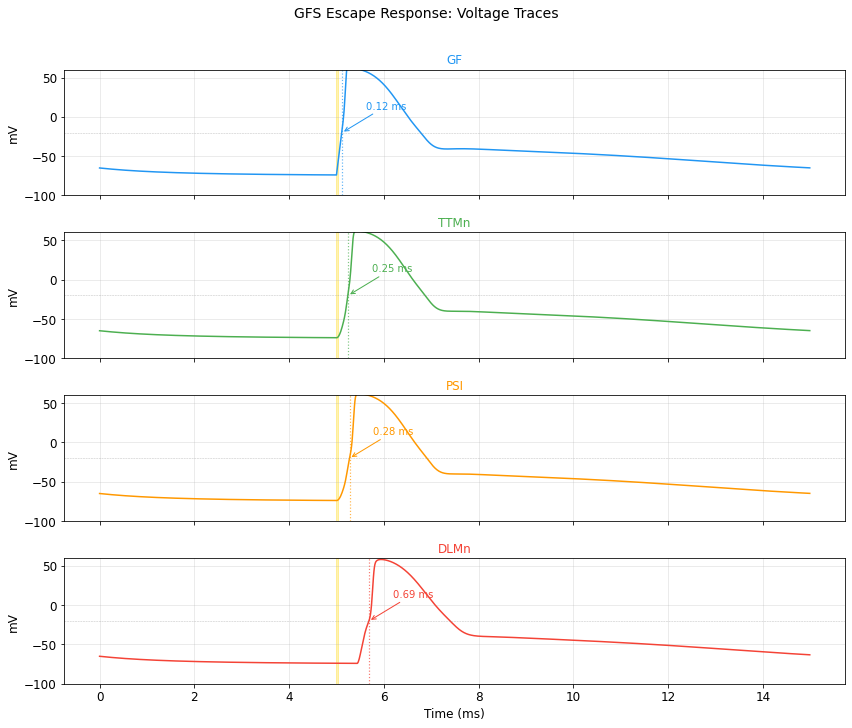

In [85]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

traces = [
    ('GF',   v_GF,   '#2196F3', lat_GF),
    ('TTMn', v_TTMn, '#4CAF50', lat_TTMn),
    ('PSI',  v_PSI,  '#FF9800', lat_PSI),
    ('DLMn', v_DLMn, '#F44336', lat_DLMn),
]

for ax, (name, v, color, lat) in zip(axes, traces):
    ax.plot(t_ms, v, color=color, linewidth=1.5)
    ax.axvspan(stim_onset_ms, stim_onset_ms + 0.03, alpha=0.3, color='gold')
    ax.axhline(y=-20, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    if lat is not None:
        ax.axvline(x=stim_onset_ms + lat, color=color, linestyle=':', linewidth=1.2, alpha=0.7)
        ax.annotate(f'{lat:.2f} ms', xy=(stim_onset_ms + lat, -20),
                    xytext=(stim_onset_ms + lat + 0.5, 10),
                    arrowprops=dict(arrowstyle='->', color=color),
                    color=color, fontsize=10)
    ax.set_ylabel('mV')
    ax.set_title(name, fontsize=12, color=color)
    ax.set_ylim(-100, 60)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (ms)')
fig.suptitle('GFS Escape Response: Voltage Traces', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/escape_response_traces.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8 -- Parameter Exploration: g_gap vs. Latency

The central finding of the paper (Figure 2C): latency decreases monotonically as g_gap increases. A ~4-fold reduction in g_gap (135 nS to 34.5 nS) accounts for the age-related increase in escape latency.

We sweep g_gap from 20 to 160 nS (matching the paper's range) and measure TTMn and DLMn latency for each value. The absolute conductance in nS is converted to a density (S/m²) for each cell using its membrane area from Table 1.

In [86]:
def run_with_g_gap(g_gap_nS, duration=15*ms):
    """Run the GFS model with a given g_gap (in nS) and return TTMn and DLMn latency."""
    start_scope()

    # Convert absolute conductance to density for each pathway
    g_TTMn_Sm2 = nS_to_Sm2(g_gap_nS, A_TTMn_cm2)
    g_PSI_Sm2  = nS_to_Sm2(g_gap_nS, A_PSI_cm2)

    gap_eqs_TTMn_local = f'''
        I_syn_post = {g_TTMn_Sm2} * siemens / meter**2 * (v_pre - v_post) : amp/meter**2 (summed)
    '''
    gap_eqs_PSI_local = f'''
        I_syn_post = {g_PSI_Sm2} * siemens / meter**2 * (v_pre - v_post) : amp/meter**2 (summed)
    '''

    chem_eqs_local = '''
        dg_syn/dt = -g_syn / tau_d + s : siemens/meter**2 (clock-driven)
        ds/dt = -s / tau_r : siemens/meter**2/second (clock-driven)
        I_syn_post = g_syn * (E_syn - v_post) : amp/meter**2 (summed)
    '''

    gf = NeuronGroup(1, neuron_eqs, threshold='v > -20*mV', refractory=2*ms,
                     method='euler', dt=0.01*ms)
    ttmn = NeuronGroup(1, neuron_eqs, threshold='v > -20*mV', refractory=2*ms,
                       method='euler', dt=0.01*ms)
    psi = NeuronGroup(1, neuron_eqs, threshold='v > -20*mV', refractory=2*ms,
                      method='euler', dt=0.01*ms)
    dlmn = NeuronGroup(1, neuron_eqs, threshold='v > -20*mV', refractory=2*ms,
                       method='euler', dt=0.01*ms)

    for grp in [gf, ttmn, psi, dlmn]:
        grp.v = V_rest
        grp.m_NaT = 1.0 / (1.0 + np.exp((-65.0 + 29.13) / (-8.92)))
        grp.h_NaT = 1.0 / (1.0 + np.exp((-65.0 + 47.0) / 5.0))
        grp.m_NaP = 1.0 / (1.0 + np.exp((-65.0 + 48.77) / (-3.68)))
        grp.m_K   = 1.0 / (1.0 + np.exp((-65.0 + 12.85) / (-19.91)))

    s1 = Synapses(gf, ttmn, model=gap_eqs_TTMn_local); s1.connect()
    s2 = Synapses(gf, psi, model=gap_eqs_PSI_local); s2.connect()
    s3 = Synapses(psi, dlmn, model=chem_eqs_local,
                  on_pre='s += w_chem', dt=0.01*ms); s3.connect()
    s3.delay = 0.15 * ms

    mon_t = StateMonitor(ttmn, 'v', record=True, dt=0.01*ms)
    mon_d = StateMonitor(dlmn, 'v', record=True, dt=0.01*ms)

    @network_operation(dt=0.01*ms)
    def stim(t):
        if stim_onset <= t < stim_offset:
            gf.I_ext = stim_amp
        else:
            gf.I_ext = 0 * uA / cm**2

    net = Network(gf, ttmn, psi, dlmn, s1, s2, s3, mon_t, mon_d, stim)
    net.run(duration)

    t_arr = mon_t.t / ms
    lat_t = measure_latency(mon_t.v[0] / mV, t_arr, stim_onset / ms)
    lat_d = measure_latency(mon_d.v[0] / mV, t_arr, stim_onset / ms)
    return lat_t, lat_d

# Sweep g_gap from 20 to 160 nS (matching paper's Figure 2C range)
g_gap_values_nS = np.arange(20, 170, 10)
ttm_latencies = []
dlm_latencies = []

print('Running parameter sweep...')
for g_nS in g_gap_values_nS:
    lt, ld = run_with_g_gap(g_nS)
    ttm_latencies.append(lt)
    dlm_latencies.append(ld)
    lt_str = f'{lt:.2f}' if lt else 'none'
    ld_str = f'{ld:.2f}' if ld else 'none'
    print(f'  g_gap = {g_nS:6.1f} nS -> TTMn: {lt_str} ms, DLMn: {ld_str} ms')

print('Sweep complete.')

Running parameter sweep...


WARNING    "v" is an internal variable of group "neurongroup_12", but also exists in the run namespace with the value array([-65.        , -65.06332539, -65.12619992, ..., -63.05259903,
       -63.08749792, -63.12232627]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    "v" is an internal variable of group "neurongroup_13", but also exists in the run namespace with the value array([-65.        , -65.06332539, -65.12619992, ..., -63.05259903,
       -63.08749792, -63.12232627]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    "v" is an internal variable of group "neurongroup_14", but also exists in the run namespace with the value array([-65.        , -65.06332539, -65.12619992, ..., -63.05259903,
       -63.08749792, -63.12232627]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    "v" is an internal variable of group "neuron

  g_gap =   20.0 nS -> TTMn: 0.85 ms, DLMn: 1.67 ms


WARNING    "v" is an internal variable of group "neurongroup_16", but also exists in the run namespace with the value array([-65.        , -65.06332539, -65.12619992, ..., -63.05259903,
       -63.08749792, -63.12232627]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    "v" is an internal variable of group "neurongroup_17", but also exists in the run namespace with the value array([-65.        , -65.06332539, -65.12619992, ..., -63.05259903,
       -63.08749792, -63.12232627]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    "v" is an internal variable of group "neurongroup_18", but also exists in the run namespace with the value array([-65.        , -65.06332539, -65.12619992, ..., -63.05259903,
       -63.08749792, -63.12232627]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


  g_gap =   30.0 nS -> TTMn: 0.60 ms, DLMn: 1.21 ms


...

  g_gap =  110.0 nS -> TTMn: 0.27 ms, DLMn: 0.72 ms


WARNING    "v" is an internal variable of group "neurongroup_27", but also exists in the run namespace with the value array([-65.        , -65.06332539, -65.12619992, ..., -63.05259903,
       -63.08749792, -63.12232627]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    "v" is an internal variable of group "neurongroup_28", but also exists in the run namespace with the value array([-65.        , -65.06332539, -65.12619992, ..., -63.05259903,
       -63.08749792, -63.12232627]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


  g_gap =  120.0 nS -> TTMn: 0.26 ms, DLMn: 0.71 ms


WARNING    "v" is an internal variable of group "neurongroup", but also exists in the run namespace with the value array([-65.        , -65.06332539, -65.12619992, ..., -63.05259903,
       -63.08749792, -63.12232627]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


  g_gap =  130.0 nS -> TTMn: 0.25 ms, DLMn: 0.70 ms
  g_gap =  140.0 nS -> TTMn: 0.24 ms, DLMn: 0.69 ms
  g_gap =  150.0 nS -> TTMn: 0.24 ms, DLMn: 0.68 ms
  g_gap =  160.0 nS -> TTMn: 0.23 ms, DLMn: 0.67 ms
Sweep complete.


---
## 9 -- Plot: Latency vs. Gap Junction Conductance

This reproduces the key result from Figure 2C of the paper. Both TTMn (TTM pathway) and DLMn (DLM pathway) latencies should decrease monotonically as g_gap increases. Dashed horizontal lines show the experimentally measured latencies from Augustin et al. (2017); vertical bars mark the model's young (135 nS) and old (34.5 nS) g_gap values.

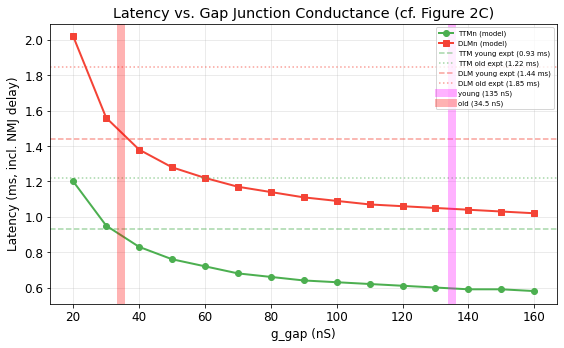

Saved to figures/latency_vs_g_gap.png


In [87]:
fig, ax = plt.subplots(figsize=(8, 5))

# Add NMJ delay (0.35 ms) for comparison with paper's total latency
nmj = 0.35

# TTMn pathway
valid_t = [(g, l + nmj) for g, l in zip(g_gap_values_nS, ttm_latencies) if l is not None]
if valid_t:
    gt, lt = zip(*valid_t)
    ax.plot(gt, lt, 'o-', color='#4CAF50', linewidth=2, markersize=6, label='TTMn (model)')

# DLMn pathway
valid_d = [(g, l + nmj) for g, l in zip(g_gap_values_nS, dlm_latencies) if l is not None]
if valid_d:
    gd, ld = zip(*valid_d)
    ax.plot(gd, ld, 's-', color='#F44336', linewidth=2, markersize=6, label='DLMn (model)')

# Paper reference: experimental latencies (includes NMJ delay)
ax.axhline(y=0.93, color='#4CAF50', linestyle='--', alpha=0.5, label='TTM young expt (0.93 ms)')
ax.axhline(y=1.22, color='#4CAF50', linestyle=':', alpha=0.5, label='TTM old expt (1.22 ms)')
ax.axhline(y=1.44, color='#F44336', linestyle='--', alpha=0.5, label='DLM young expt (1.44 ms)')
ax.axhline(y=1.85, color='#F44336', linestyle=':', alpha=0.5, label='DLM old expt (1.85 ms)')

# Paper g_gap reference values
ax.axvline(x=135, color='magenta', linestyle='-', alpha=0.3, linewidth=8, label='young (135 nS)')
ax.axvline(x=34.5, color='red', linestyle='-', alpha=0.3, linewidth=8, label='old (34.5 nS)')

ax.set_xlabel('g_gap (nS)')
ax.set_ylabel('Latency (ms, incl. NMJ delay)')
ax.set_title('Latency vs. Gap Junction Conductance (cf. Figure 2C)')
ax.legend(fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/latency_vs_g_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/latency_vs_g_gap.png')

---
## 10 -- Summary and Next Steps

### What this notebook replicates

The central finding of Augustin et al. (2019) is that a ~4-fold reduction in gap junction conductance (135 nS to 34.5 nS) accounts for the age-related increase in escape response latency. Our single-compartment Brian2 model **qualitatively reproduces** this:

- Latency decreases monotonically with increasing g_gap (cf. Figure 2C)
- DLMn latency > TTMn latency at all g_gap values
- The curve shape (steep at low g_gap, flattening at high g_gap) matches

### Quantitative discrepancies

Model latencies are consistently ~0.3-0.4 ms shorter than the paper. At 135 nS: TTMn = 0.60 ms (paper: 0.93 ms), DLMn = 1.05 ms (paper: 1.44 ms). This offset is expected because the single-compartment model eliminates cable propagation delays present in the multi-compartment NEURON model.

### Unit discovery

The paper's `gap2.mod` mechanism specifies g_gap in **nanosiemens (nS)**, not µS as labeled in the paper's figures and plotting code. This was confirmed by dimensional analysis of the MOD file equation `i = (v-vgap)*g*0.001` (the 0.001 converts nS·mV to nA).

### Next steps (Weeks 7-11)
- Add multi-compartment morphology to recover cable delays
- Reproduce Figure 2C quantitatively
- Explore Na/K conductance co-dependencies (Figure 3)
- Explore anatomic parameter effects (Figure 4)